# Intro to QCut CutOptions

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import CXGate, RZZGate
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

import QCut as ck
from QCut import CutOptions, cut, cutGate

QCut allows configuring some options related to the circuit cutting, finding, and execution processes.
All of these options are configured with a single `CutOptions` object that is passed to `.run()` or `.get_locations_and_subcircuits()`. `CutOptions` allows defining the following options:

- `consolidate`: whether to merge consecutive cut gates into a single cut gate saving on experiment circuits and overhead
    - `auto` (default), `always` or `never`. `auto` compares cost with `joint_rotation_cuts` applied before consolidation since this sometimes results in cheaper decompositions.

- `joint_rotation_cuts`: whether to jointly cut parallel 2 qubit rotation gates using a joint decomposition. The joint decomposition costs strictly less, both in circuits and overhead, than decomposing separately
    - `True` (default) or `False` 

- `wire_cut_communication`: whether to use a wire cutting decomposition utilising one-way classical communication (LOCC) between subcircuits. Leads to a decomposition with fewer circuits. Also achieves smaller overheads on parallel blocks of more than 2 wire cuts.
    - `auto` (default), `always` or `never`. `auto` applies LOCC wire cuts on blocks of at least 2 parallel wire cuts and otherwise defaults to non-communicating decomposition.

- `expansion`: whether to exactly enumerate through all of the generated experiment circuits from the decomposition or to sample it.
    - `auto` (default), `exact` or `sample`. `auto` chooses between `exact` and `sample` based on `max_exact_groups`

- `max_exact_groups`: the maximum number of experiment groups to exactly enumerate through
    - `int` default 1000

- `num_samples`: number of samples to take from the decomposition when `expansion` is set to `sample`
  - defaults to `max_exact_groups`

- `finder_candidates`: how many candidate partitions to compare in automatic cut finding
    - `int` default 5

- `seed`: seed passed to the automatic cut finder and used for sampling when `expansion` is set to `sample`

Below you can also see the default values. They can also be accessed via `ck.DEFAULT_OPTIONS`

In [117]:
options = CutOptions(
    consolidate="auto",
    joint_rotation_cuts=True,
    wire_cut_communication="auto",
    expansion="auto",
    max_exact_groups=1000,
    num_samples=None,
    finder_candidates=5,
    seed=None,
)

Now lets see some of them in action

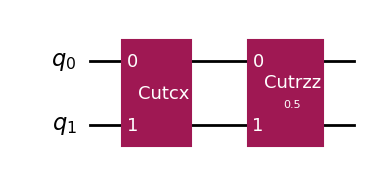

In [118]:
qc = QuantumCircuit(2)
qc.append(**cutGate(CXGate(), 0, 1))
qc.append(**cutGate(RZZGate(0.5), 0, 1))

qc.draw("mpl")

In [119]:
for mode in ["auto", "never", "always"]:
    options = CutOptions(
        consolidate=mode,
    )

    cut_circuit = ck.get_locations_and_subcircuits(qc, options=options)

    observables = SparsePauliOp(["ZZ"])

    cut_experiment = ck.get_experiment_circuits(cut_circuit, observables)

    print(f"Generated {cut_experiment.num_circuits} circuits. In mode {mode}.")

Generated 12 circuits. In mode auto.
Generated 72 circuits. In mode never.
Generated 12 circuits. In mode always.


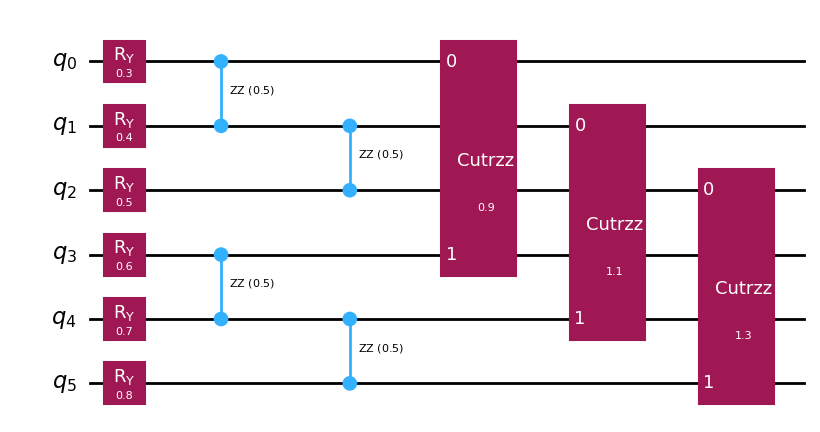

In [120]:
def parallel_rotations(n_gates, cut_it=True):
    """n_gates parallel rzz across a two-way split, both sides connected."""
    width = 2 * n_gates
    circuit = QuantumCircuit(width)
    for qubit in range(width):
        circuit.ry(0.3 + 0.1 * qubit, qubit)
    for index in range(n_gates - 1):
        circuit.rzz(0.5, index, index + 1)
        circuit.rzz(0.5, n_gates + index, n_gates + index + 1)
    for index in range(n_gates):
        theta = 0.9 + 0.2 * index
        if cut_it:
            circuit.append(**cutGate(RZZGate(theta), index, n_gates + index))
        else:
            circuit.rzz(theta, index, n_gates + index)
    return circuit


parallel_circuit = parallel_rotations(3, cut_it=True)

parallel_circuit.draw("mpl")

In [121]:
for mode in [True, False]:
    options = CutOptions(
        joint_rotation_cuts=mode,
    )

    cut_circuit = ck.get_locations_and_subcircuits(parallel_circuit, options=options)

    observables = SparsePauliOp(["ZZZZZZ"])

    cut_experiment = ck.get_experiment_circuits(cut_circuit, observables)

    print(f"Generated {cut_experiment.num_circuits} circuits. In mode {mode}.")

Generated 264 circuits. In mode True.
Generated 432 circuits. In mode False.


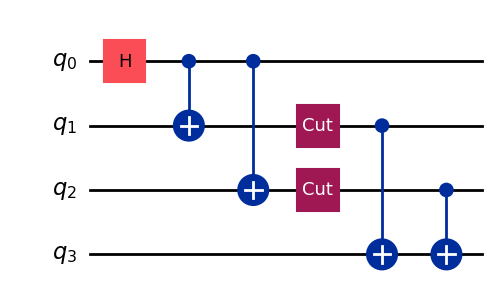

In [122]:
wire_cut = QuantumCircuit(4)
wire_cut.h(0)
wire_cut.cx(0, 1)
wire_cut.cx(0, 2)
wire_cut.append(cut(), [1])
wire_cut.append(cut(), [2])
wire_cut.cx(1, 3)
wire_cut.cx(2, 3)

wire_cut.draw("mpl")

In [123]:
for mode in ["auto", "never", "always"]:
    options = CutOptions(
        wire_cut_communication=mode,
    )

    cut_circuit = ck.get_locations_and_subcircuits(wire_cut, options=options)

    observables = SparsePauliOp(["ZZZZ"])

    cut_experiment = ck.get_experiment_circuits(cut_circuit, observables)

    print(f"Generated {cut_experiment.num_circuits} circuits. In mode {mode}.")

Generated 56 circuits. In mode auto.
Generated 128 circuits. In mode never.
Generated 56 circuits. In mode always.


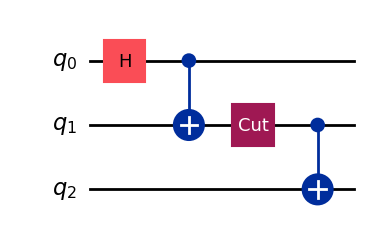

In [124]:
wire_cut_single = QuantumCircuit(3)
wire_cut_single.h(0)
wire_cut_single.cx(0, 1)
wire_cut_single.append(cut(), [1])
wire_cut_single.cx(1, 2)

wire_cut_single.draw("mpl")

In [165]:
for mode in ["auto", "never", "always"]:
    options = CutOptions(
        wire_cut_communication=mode,
    )

    cut_circuit = ck.get_locations_and_subcircuits(wire_cut_single, options=options)

    observables = SparsePauliOp(["ZZZ"])

    cut_experiment = ck.get_experiment_circuits(cut_circuit, observables)

    print(f"Generated {cut_experiment.num_circuits} circuits. In mode {mode}.")

Generated 16 circuits. In mode auto.
Generated 16 circuits. In mode never.
Generated 12 circuits. In mode always.


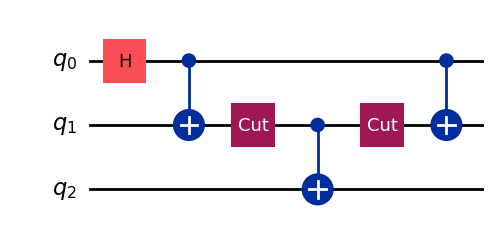

In [126]:
wire_cut_sequence = QuantumCircuit(3)
wire_cut_sequence.h(0)
wire_cut_sequence.cx(0, 1)
wire_cut_sequence.append(cut(), [1])
wire_cut_sequence.cx(1, 2)
wire_cut_sequence.append(cut(), [1])
wire_cut_sequence.cx(0, 1)

wire_cut_sequence.draw("mpl")

In [127]:
for mode in ["auto", "never", "always"]:
    options = CutOptions(
        wire_cut_communication=mode,
    )

    cut_circuit = ck.get_locations_and_subcircuits(wire_cut_sequence, options=options)

    observables = SparsePauliOp(["ZZZ"])

    cut_experiment = ck.get_experiment_circuits(cut_circuit, observables)

    print(f"Generated {cut_experiment.num_circuits} circuits. In mode {mode}.")

Generated 128 circuits. In mode auto.
Generated 128 circuits. In mode never.
Generated 96 circuits. In mode always.


Notice that here the non-parallel wire cuts actually lead to more circuits in `auto` mode. This is due to how the implementation affects the actual achieved overhead. The ideal overhead of the LOCC cuts is always better than the non-communicating decomposition. However due to how it needs to be implemented to be efficient on actual hardware (no jobs with single circuit and single shot) the achieved overhead suffers somewhat and is slightly worse than the non-communicative one on non-parallel wire cuts. This is why `auto` sometimes chooses to generate more circuits. In the end this is a situation dependent tradeoff where you are choosing between more samples/shots or more circuits.

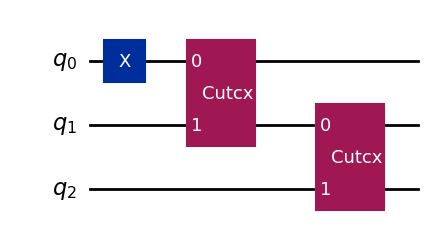

In [155]:
ghz = QuantumCircuit(3)
ghz.x(0)
ghz.append(**cutGate(CXGate(), 0, 1))
ghz.append(**cutGate(CXGate(), 1, 2))

ghz.draw("mpl")

In [163]:
parallel_circuit = parallel_rotations(3, cut_it=True)

for samples in [100, 3000, "exact"]:
    if samples == "exact":
        options = CutOptions(
            expansion="exact",
        )
    else:
        options = CutOptions(
            num_samples=samples,
            expansion="sample",
        )

    cut_circuit = ck.get_locations_and_subcircuits(parallel_circuit, options=options)

    observables = SparsePauliOp(["ZZZZZZ"])

    cut_experiment = ck.get_experiment_circuits(cut_circuit, observables)

    print(f"Generated {cut_experiment.num_circuits} circuits.")

    res = ck.run_experiments(cut_experiment, backend=AerSimulator())

    expectation_values = ck.estimate_expectation_values(res)

    if samples == "exact":
        print(f"ZZ = {expectation_values[0]} for exact expansion.")
    else:
        print(f"ZZ = {expectation_values[0]} for {samples} samples.")

Generated 120 circuits.
ZZ = 0.21840353784399721 for 100 samples.
Generated 264 circuits.
ZZ = 0.3867275818121978 for 3000 samples.
Generated 264 circuits.
ZZ = 0.3145307898274838 for exact expansion.
